In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
data = pd.read_csv('dataset.csv', encoding="windows-1252")

In [39]:
data.head()

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
0,2015,1,5,Weekday,0.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,1ST & FESS,39.159207,-86.525874
1,2015,1,6,Weekday,1500.0,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,2ND & COLLEGE,39.161440,-86.534848
2,2015,1,6,Weekend,2300.0,2-Car,Non-incapacitating,DISREGARD SIGNAL/REG SIGN,BASSWOOD & BLOOMFIELD,39.149780,-86.568890
3,2015,1,7,Weekend,900.0,2-Car,Non-incapacitating,FAILURE TO YIELD RIGHT OF WAY,GATES & JACOBS,39.165655,-86.575956
4,2015,1,7,Weekend,1100.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,W 3RD,39.164848,-86.579625


In [40]:
import plotly.express as px

In [41]:
fig = px.scatter_mapbox(data_frame=data, lat="Latitude", lon="Longitude", color="Collision Type",
                        center={"lat":39, "lon":-86.5}, mapbox_style= "open-street-map",
                        hover_data=["Injury Type"], height=700, width=1200)
fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1080\989110019.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



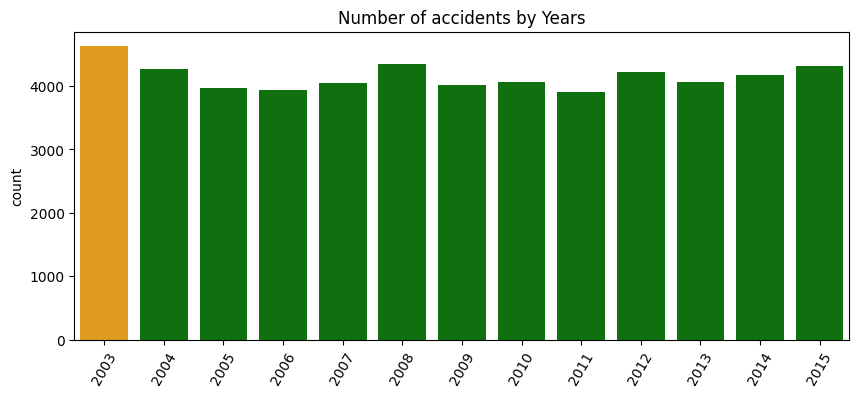

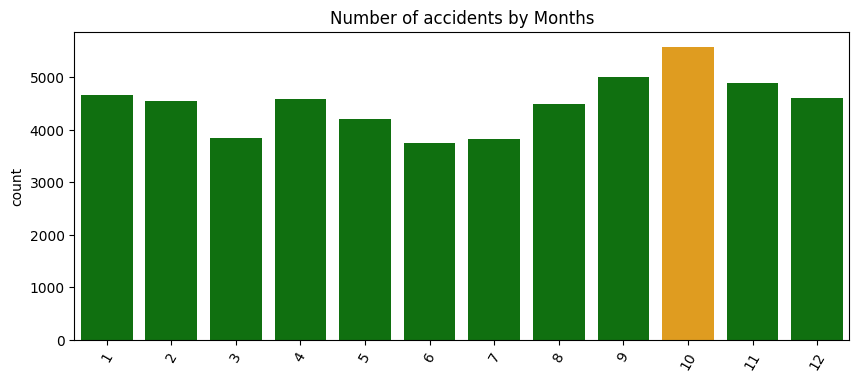

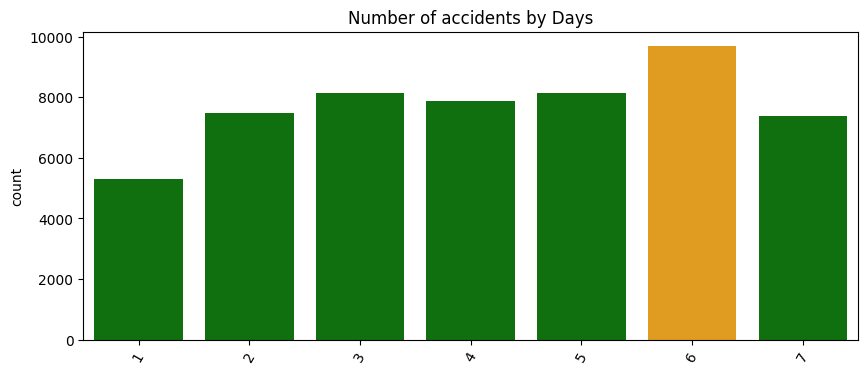

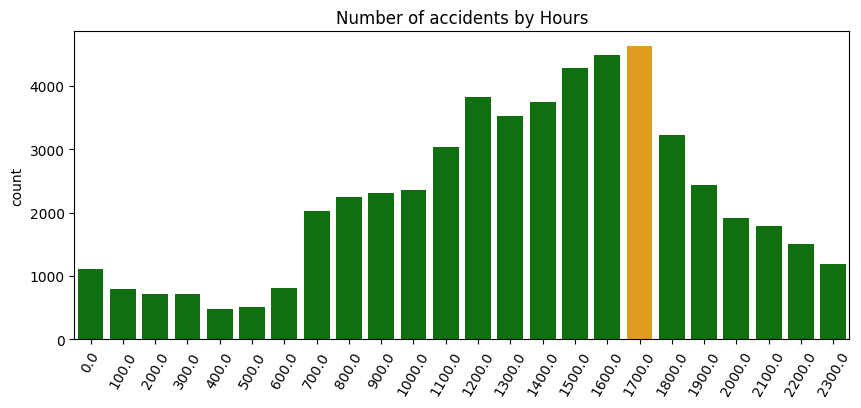

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Список временных показателей
datetime_list = ['Year', 'Month', 'Day', 'Hour']

for i in datetime_list:
    # Группировка данных по временному показателю
    grouped = data.groupby(i)[i].count().reset_index(name="count")

    # Создание графика
    plt.figure(figsize=(10, 4))

    # Определение цветовой палитры
    cols = ["green" if (x < max(grouped["count"])) else "orange" for x in grouped["count"]]

    # Построение barplot с явным указанием hue
    sns.barplot(data=grouped, x=i, y="count", palette=cols, hue=i, legend=False)

    # Настройка графика
    plt.title(f"Number of accidents by {i}s")
    plt.xticks(rotation=60)
    plt.xlabel("")
    plt.show()

<Axes: ylabel='Primary Factor'>

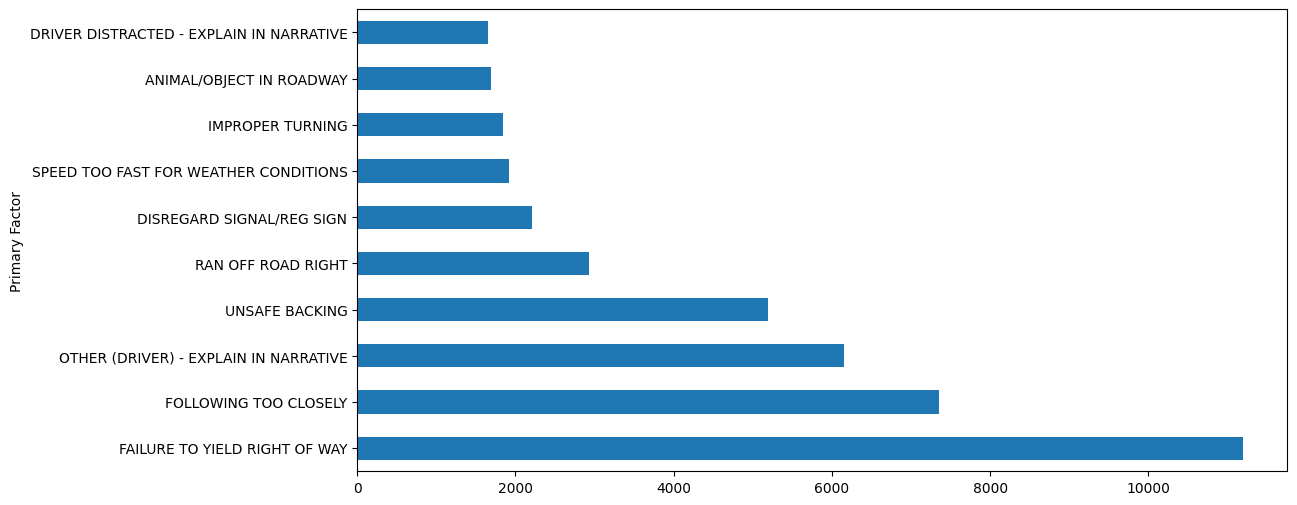

In [43]:
plt.figure(figsize=(12,6))
data['Primary Factor'].value_counts().head(10).plot(kind='barh')

In [44]:
grouped = data.groupby('Weekend?')['Weekend?'].count().reset_index(name="count")
grouped

,Weekend?,count
0,Weekday,40604
1,Weekend,13271


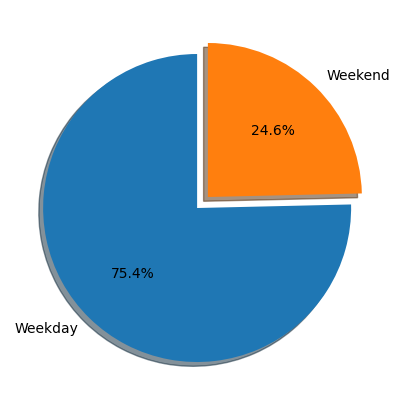

In [45]:
plt.figure(figsize=(10,5))
plt.pie(x=grouped['count'], labels=grouped['Weekend?'], shadow=True, startangle=90, autopct='%0.1f%%', explode=[0.05,0.05])
plt.show()

In [46]:
grouped = data.groupby('Injury Type')['Injury Type'].count().reset_index(name='count')
grouped

,Injury Type,count
0,Fatal,115
1,Incapacitating,1089
2,No injury/unknown,41603
3,Non-incapacitating,11136


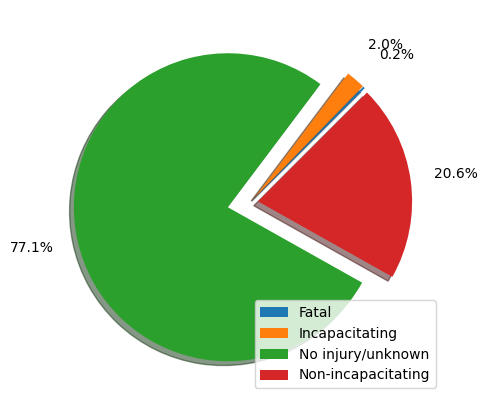

In [47]:
plt.figure(figsize=(10,5))
plt.pie(x=grouped['count'], shadow=True, startangle=45, autopct='%0.1f%%', pctdistance=1.3, explode=[0.05, 0.05, 0.15, 0.05])
plt.legend(labels=grouped['Injury Type'])
plt.show()

In [48]:
data['Collision Type'].value_counts()

Collision Type
2-Car               37606
1-Car               10245
3+ Cars              3152
Moped/Motorcycle     1007
Bus                   850
Pedestrian            609
Cyclist               468
Name: count, dtype: int64

In [49]:
import numpy as np
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

In [50]:
data

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
0,2015,1,5,Weekday,0.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,1ST & FESS,39.159207,-86.525874
1,2015,1,6,Weekday,1500.0,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,2ND & COLLEGE,39.161440,-86.534848
2,2015,1,6,Weekend,2300.0,2-Car,Non-incapacitating,DISREGARD SIGNAL/REG SIGN,BASSWOOD & BLOOMFIELD,39.149780,-86.568890
3,2015,1,7,Weekend,900.0,2-Car,Non-incapacitating,FAILURE TO YIELD RIGHT OF WAY,GATES & JACOBS,39.165655,-86.575956
4,2015,1,7,Weekend,1100.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,W 3RD,39.164848,-86.579625
...,...,...,...,...,...,...,...,...,...,...,...
53938,2003,10,6,Weekday,1700.0,2-Car,No injury/unknown,IMPROPER LANE USAGE,DUNN & WHITE LOT WEST,0.000000,0.000000
53939,2003,11,3,Weekday,800.0,1-Car,No injury/unknown,UNSAFE SPEED,RED OAK & SR446,0.000000,0.000000
53940,2003,12,5,Weekday,1200.0,2-Car,No injury/unknown,BRAKE FAILURE OR DEFECTIVE,2ND ST & WALNUT,0.000000,0.000000
53941,2003,12,1,Weekend,700.0,2-Car,No injury/unknown,UNSAFE BACKING,NINETH & NORTH,0.000000,0.000000


In [51]:
data['Collision Type'].value_counts() # le

Collision Type
2-Car               37606
1-Car               10245
3+ Cars              3152
Moped/Motorcycle     1007
Bus                   850
Pedestrian            609
Cyclist               468
Name: count, dtype: int64

In [52]:
data['Injury Type'].value_counts() #One hot

Injury Type
No injury/unknown     41603
Non-incapacitating    11136
Incapacitating         1089
Fatal                   115
Name: count, dtype: int64

In [53]:
injury_ohe = pd.get_dummies(data['Injury Type'], prefix='Injury', dtype='int')
injury_ohe

,Injury_Fatal,Injury_Incapacitating,Injury_No injury/unknown,Injury_Non-incapacitating
0,0,0,1,0
1,0,0,1,0
2,0,0,0,1
3,0,0,0,1
4,0,0,1,0
...,...,...,...,...
53938,0,0,1,0
53939,0,0,1,0
53940,0,0,1,0
53941,0,0,1,0


In [54]:
data = pd.concat([data, injury_ohe], axis=1)

In [55]:
data.drop('Injury Type', axis=1, inplace=True)

In [56]:
data.drop('Reported_Location', axis=1, inplace=True)

In [57]:
le = LabelEncoder()
data['Primary Factor'] = le.fit_transform(data['Primary Factor'])

In [58]:
dict_weekend = {'Weekday': 0, 'Weekend': 1}
data['Weekend?'] = data['Weekend?'].map(dict_weekend)

In [59]:
le_collision = LabelEncoder()
data['Collision Type'] = le_collision.fit_transform(data['Collision Type'])

In [60]:
data = data.fillna(-1)

In [61]:
data = data[(data['Latitude'].between(35, 45))&(data['Longitude'].between(-90, -80))]
data

,Year,Month,Day,Weekend?,Hour,Collision Type,Primary Factor,Latitude,Longitude,Injury_Fatal,Injury_Incapacitating,Injury_No injury/unknown,Injury_Non-incapacitating
0,2015,1,5,0.0,0.0,1,27,39.159207,-86.525874,0,0,1,0
1,2015,1,6,0.0,1500.0,1,11,39.161440,-86.534848,0,0,1,0
2,2015,1,6,1.0,2300.0,1,5,39.149780,-86.568890,0,0,0,1
3,2015,1,7,1.0,900.0,1,10,39.165655,-86.575956,0,0,0,1
4,2015,1,7,1.0,1100.0,1,10,39.164848,-86.579625,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53344,2003,4,7,1.0,2000.0,0,50,39.004275,-86.581375,0,0,1,0
53345,2003,5,7,1.0,1500.0,0,50,39.002752,-86.463856,0,0,0,1
53346,2003,11,3,0.0,2300.0,0,40,38.992326,-86.537252,0,0,1,0
53347,2003,12,7,1.0,1700.0,0,50,38.991520,-86.448784,0,0,0,1


In [62]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('KMeans', KMeans(n_clusters=10))
])
pipe.fit(data[['Latitude', 'Longitude']])

,steps,"[('scaler', ...), ('KMeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [63]:
data['Cluster'] = pipe.predict(data[['Latitude', 'Longitude']])

In [64]:
fig = px.scatter_mapbox(data_frame=data, lat="Latitude", lon="Longitude", color="Cluster",
                        center={"lat":39, "lon":-86.5}, mapbox_style= "open-street-map",height=700, width=1200)
fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1080\571373535.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [65]:
grouped = data.groupby('Cluster')['Cluster'].count().reset_index(name='count')
grouped

,Cluster,count
0,0,4600
1,1,1343
2,2,8
3,3,8126
4,4,890
5,5,7968
6,6,2625
7,7,23406
8,8,10
9,9,3


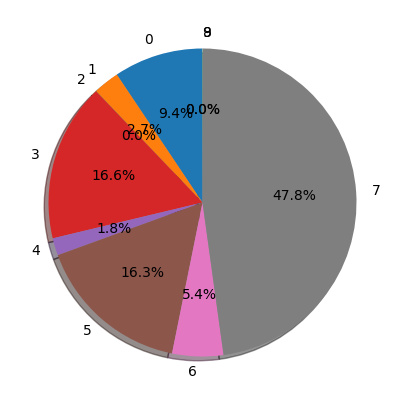

In [66]:
plt.figure(figsize=(10,5))
plt.pie(x=grouped['count'], labels=grouped['Cluster'], shadow=True, startangle=90, autopct='%0.1f%%')
plt.show()

In [67]:
centres = pipe.named_steps['KMeans'].cluster_centers_
centres = pipe.named_steps['scaler'].inverse_transform(centres)

In [68]:
pd.DataFrame(centres, columns=['Latitude_Centre', 'Longitude_Centre'])


,Latitude_Centre,Longitude_Centre
0,39.118935,-86.532689
1,39.278979,-86.509392
2,40.312322,-86.894307
3,39.146195,-86.587872
4,39.008139,-86.505084
5,39.164830,-86.487415
6,39.232060,-86.617215
7,39.171356,-86.532511
8,40.177503,-85.585869
9,40.504196,-88.956665


In [69]:
from sklearn.cluster import DBSCAN

In [70]:
# hyperparams = [
#     [0.2, 40],
#     [0.2, 50]
# ]

# for eps, n in hyperparams:
#     pipe_dbscan = Pipeline([
#         ('scaler', StandardScaler()),
#         ('DBSCAN', DBSCAN(eps=eps, min_samples=n))
#     ])

#     data['Cluster'] = pipe_dbscan.fit_predict(data[['Collision Type']])

#     fig = px.scatter_mapbox(data_frame=data, lat="Latitude", lon="Longitude", color="Cluster",
#                         center={"lat":39, "lon":-86.5}, mapbox_style= "open-street-map",height=700, width=1200, title=f'DBSCAN with eps={eps} and n={n}')
#     fig.show()